In [ ]:
import seaborn as sns
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
result_path = Path("../results/soft_mrs_analysis")
save_path = Path("diagrams/soft_mrs_analysis")
save_path.mkdir(exist_ok=True, parents=True)

## Folktables Income

In [ ]:
dict_list = []

soft_mrs_analysis_file_name = result_path / "linear" / "folktables_income" / "less_positive_class" /\
        "0.1" / "soft_mrs" 
soft_mrs_analysis_mmd = pd.read_json(str(soft_mrs_analysis_file_name / "mmds/mmds.json"), 
                                        orient="records", typ="series", convert_axes=False)

soft_mrs_analysis_relative_bias = pd.read_json(str(soft_mrs_analysis_file_name / "relative_bias/relative_biases.json"), 
                                        orient="records", typ="series", convert_axes=False)
soft_mrs_analysis_aurocs = pd.read_json(str(soft_mrs_analysis_file_name / "aurocs/aurocs.json"), 
                                        orient="records", typ="series", convert_axes=False)
soft_mrs_analysis_wasserstein = pd.read_json(str(soft_mrs_analysis_file_name / "wassersteins/wassersteins.json"), 
                                        orient="records", typ="series", convert_axes=False)
dict_list.append(
    {
        "bias_type": "less_positive_class",
        "bias_strength": 0.1,
        "MMDs": soft_mrs_analysis_mmd.values,
        "Relative Bias": soft_mrs_analysis_relative_bias.values,
        "AUROC": soft_mrs_analysis_aurocs,
    }
                            )
result_df = pd.DataFrame(data=dict_list)

In [ ]:
linear_mmd = result_df["MMDs"].values[0]
linear_relative_bias = result_df["Relative Bias"].values[0]
linear_aurocs = result_df["AUROC"].values[0]

In [ ]:
linear_mmd = np.concatenate(linear_mmd).reshape(len(linear_mmd),*np.shape(linear_mmd[0]))
linear_aurocs = np.concatenate(linear_aurocs).reshape(len(linear_aurocs),*np.shape(linear_aurocs[0]))
linear_relative_bias = np.concatenate(linear_relative_bias).reshape(len(linear_relative_bias),*np.shape(linear_relative_bias[0]))

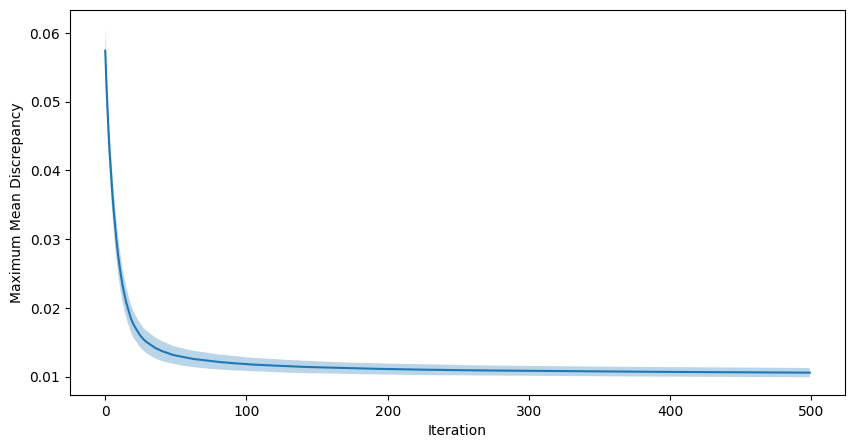

In [ ]:
plt.figure(figsize=(10, 5))
mean_linear_mmd = np.mean(linear_mmd, axis=0)[:500]
std_linear_mmd = np.std(linear_mmd, axis=0)[:500]

sns.lineplot(mean_linear_mmd).set(xlabel="Iteration", ylabel="Maximum Mean Discrepancy")
plt.fill_between(x= list(range(len(mean_linear_mmd))), y1=mean_linear_mmd + std_linear_mmd, 
                 y2=mean_linear_mmd - std_linear_mmd, alpha=0.3)
plt.savefig(save_path / "folktables_income_mmds.pdf", bbox_inches = 'tight', pad_inches = 0)

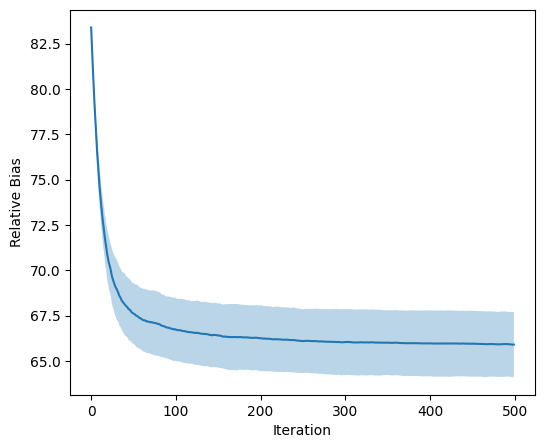

In [ ]:
plt.figure(figsize=(6, 5))
mean_linear_relative_bias = np.mean(linear_relative_bias, axis=0)[:500]
std_linear_relative_bias = np.std(linear_relative_bias, axis=0)[:500]

sns.lineplot(mean_linear_relative_bias).set(xlabel="Iteration", ylabel="Relative Bias")
plt.fill_between(x= list(range(len(mean_linear_relative_bias))), y1=mean_linear_relative_bias + std_linear_relative_bias, 
                 y2=mean_linear_relative_bias - std_linear_relative_bias, alpha=0.3)
plt.savefig(save_path / "folktables_income_relative_bias.pdf", bbox_inches = 'tight', pad_inches = 0)

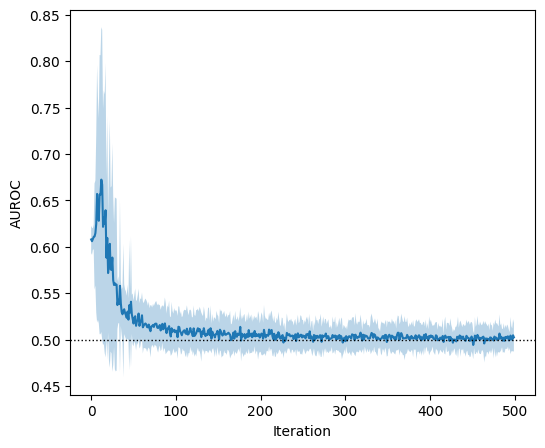

In [ ]:
plt.figure(figsize=(6, 5))

mean_linear_aurocs = np.mean(linear_aurocs, axis=0)[:500]
std_linear_aurocs = np.std(linear_aurocs, axis=0)[:500]

sns.lineplot(mean_linear_aurocs).set(xlabel="Iteration", ylabel="AUROC")
plt.fill_between(x= list(range(len(mean_linear_aurocs))), y1=mean_linear_aurocs + std_linear_aurocs, 
                 y2=mean_linear_aurocs - std_linear_aurocs, alpha=0.3)
plt.axhline(y=0.5, color="black", linestyle="dotted", linewidth=1) 
plt.savefig(save_path / "folktables_income_aurocs.pdf", bbox_inches = 'tight', pad_inches = 0)

## GBS-Allensbach

In [ ]:
dict_list = []

soft_mrs_analysis_file_name = result_path / "linear" / "gbs_allensbach" / "none" /\
        "0.1" / "soft_mrs" 
soft_mrs_analysis_mmd = pd.read_json(str(soft_mrs_analysis_file_name / "mmds/mmds.json"), 
                                        orient="records", typ="series", convert_axes=False)

soft_mrs_analysis_relative_bias = pd.read_json(str(soft_mrs_analysis_file_name / "relative_bias/relative_biases.json"), 
                                        orient="records", typ="series", convert_axes=False)
soft_mrs_analysis_aurocs = pd.read_json(str(soft_mrs_analysis_file_name / "aurocs/aurocs.json"), 
                                        orient="records", typ="series", convert_axes=False)
soft_mrs_analysis_wasserstein = pd.read_json(str(soft_mrs_analysis_file_name / "wassersteins/wassersteins.json"), 
                                        orient="records", typ="series", convert_axes=False)
dict_list.append(
    {
        "bias_type": "none",
        "bias_strength": 0.1,
        "MMDs": soft_mrs_analysis_mmd.values,
        "AUROC": soft_mrs_analysis_aurocs,
        "Wasserstein": soft_mrs_analysis_wasserstein,
    }
                            )
result_df = pd.DataFrame(data=dict_list)

In [ ]:
linear_mmd = result_df["MMDs"].values[0]
linear_aurocs = result_df["AUROC"].values[0]
linear_wassersteins = result_df["Wasserstein"].values[0]

linear_mmd = np.concatenate(linear_mmd).reshape(len(linear_mmd),*np.shape(linear_mmd[0]))
linear_aurocs = np.concatenate(linear_aurocs).reshape(len(linear_aurocs),*np.shape(linear_aurocs[0]))
linear_wassersteins = np.concatenate(linear_wassersteins).reshape(len(linear_wassersteins),*np.shape(linear_wassersteins[0]))

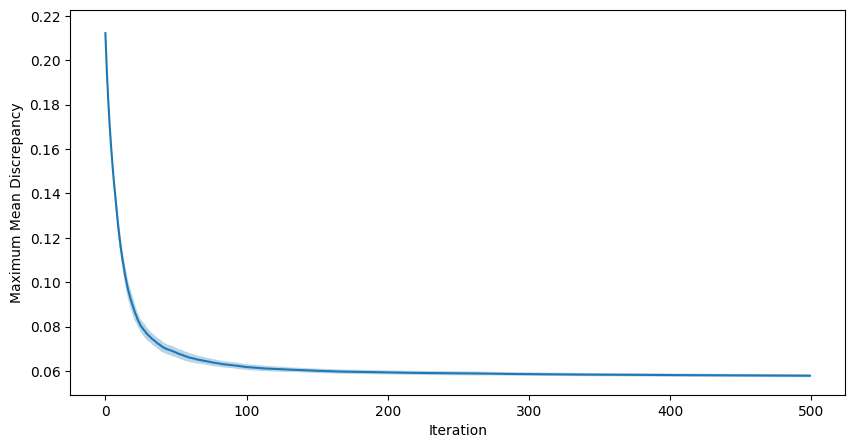

In [ ]:
plt.figure(figsize=(10, 5))
mean_linear_mmd = np.mean(linear_mmd, axis=0)[:500]
std_linear_mmd = np.std(linear_mmd, axis=0)[:500]

sns.lineplot(mean_linear_mmd).set(xlabel="Iteration", ylabel="Maximum Mean Discrepancy")
plt.fill_between(x= list(range(len(mean_linear_mmd))), y1=mean_linear_mmd + std_linear_mmd, 
                 y2=mean_linear_mmd - std_linear_mmd, alpha=0.3)
plt.savefig(save_path / "gbs_allensbach_mmds.pdf", bbox_inches = 'tight', pad_inches = 0)

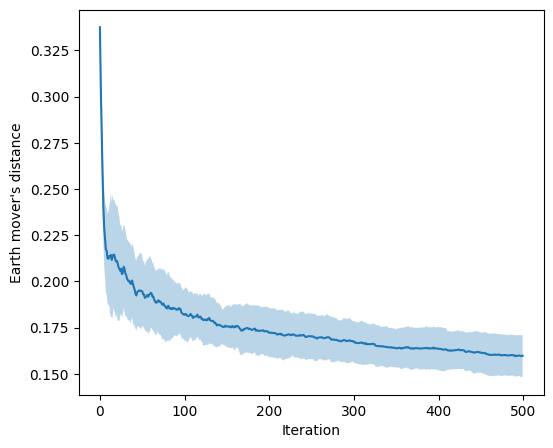

In [ ]:
plt.figure(figsize=(6, 5))
mean_linear_wasserstein = np.mean(linear_wassersteins, axis=0)[:500]
std_linear_wassersteins = np.std(linear_wassersteins, axis=0)[:500]

sns.lineplot(mean_linear_wasserstein).set(xlabel="Iteration", ylabel="Earth mover's distance")
plt.fill_between(x= list(range(len(mean_linear_wasserstein))), y1=mean_linear_wasserstein + std_linear_wassersteins, 
                 y2=mean_linear_wasserstein - std_linear_wassersteins, alpha=0.3)
plt.savefig(save_path / "gbs_allensbach_wasserstein.pdf", bbox_inches = 'tight', pad_inches = 0)

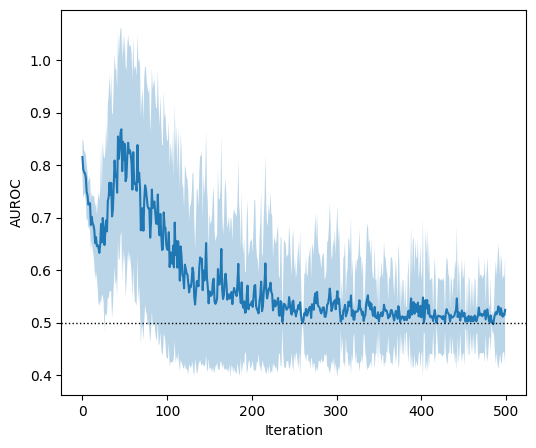

In [ ]:
plt.figure(figsize=(6, 5))
mean_linear_aurocs = np.mean(linear_aurocs, axis=0)[:500]
std_linear_aurocs = np.std(linear_aurocs, axis=0)[:500]

sns.lineplot(mean_linear_aurocs).set(xlabel="Iteration", ylabel="AUROC")
plt.fill_between(x= list(range(len(mean_linear_aurocs))), y1=mean_linear_aurocs + std_linear_aurocs, 
                 y2=mean_linear_aurocs - std_linear_aurocs, alpha=0.3)
plt.axhline(y=0.5, color="black", linestyle="dotted", linewidth=1) 
plt.savefig(save_path / "gbs_allensbach_aurocs.pdf", bbox_inches = 'tight', pad_inches = 0)